# 데이터 활용·모델링·평가 방식 재검토

제품별 RF와 라벨 없는 과거 공정 기록을 사용하는 준지도 RF를 비교한다. 앞선 튜닝만으로 충분한 재현율을 확보하지 못해 제품 구성과 추가 데이터 활용을 재검토하는 후속 탐색이다. 이미 확인한 11월 평가를 다시 사용하므로 독립적인 신규 검증이나 현장 효과를 주장하지 않는다.

필요 파일은 `labeled_data.csv`와 같은 폴더의 `unlabeled_data.csv`다. CPU로 실행한다. Drive 사용 시 먼저 연결하고 첫 셀의 DATA_PATH를 지정한다. 평가 기록에 대한 예측은 마지막 단계에서만 계산하고 선택은 제품별 조정 구간으로 제한한다.

In [1]:
# 일반적인 코랩/캐글 환경에는 아래 패키지가 준비되어 있다.
# import 오류가 있는 경우에만 다음 줄의 주석을 해제해 실행한다.
# %pip install pandas numpy scikit-learn matplotlib
from pathlib import Path
import os, sys, json, hashlib, platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, confusion_matrix, precision_recall_curve
from sklearn.inspection import permutation_importance

SEED = 42
INSPECTION_BUDGET = 0.10  # 검증 데이터의 10% 이내. 현장 요구가 아닌 분석용 가정.
DATA_PATH = None  # 예: '/content/labeled_data.csv'
if DATA_PATH is None:
    candidates = [Path('labeled_data.csv'), Path('dataset/labeled_data.csv'),
                  Path('/content/labeled_data.csv')]
    if os.environ.get('MOLDING_DATA_PATH'):
        candidates.insert(0, Path(os.environ['MOLDING_DATA_PATH']))
    if Path('/kaggle/input').exists():
        candidates.extend(Path('/kaggle/input').rglob('labeled_data.csv'))
    existing = list(dict.fromkeys(p.resolve() for p in candidates if p.is_file()))
    if len(existing) == 1:
        DATA_PATH = existing[0]
    elif len(existing) > 1:
        raise ValueError('동명 파일이 여러 개입니다. DATA_PATH를 직접 지정하세요.')
    elif 'google.colab' in sys.modules:
        from google.colab import files
        uploaded = files.upload()
        if 'labeled_data.csv' not in uploaded:
            raise ValueError('labeled_data.csv를 업로드하세요.')
        DATA_PATH = Path('labeled_data.csv')
    else:
        raise FileNotFoundError('labeled_data.csv를 연결하고 DATA_PATH를 지정하세요.')
DATA_PATH = Path(DATA_PATH)
raw = pd.read_csv(DATA_PATH, dtype={'PART_FACT_SERIAL': str})
print('Python:', platform.python_version(), 'pandas:', pd.__version__, 'sklearn:', sklearn.__version__)
print('파일:', DATA_PATH.name, '행/열:', raw.shape)
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
print('SHA256:', source_sha256)
display(raw[['TimeStamp','PART_NAME','PassOrFail','Injection_Time','Max_Injection_Pressure']].head())

Python: 3.12.14 pandas: 3.0.5 sklearn: 1.9.0
파일: labeled_data.csv 행/열: (7996, 45)
SHA256: e8d375c8e0c2cdfc309baf01ac2203fc2edb6e9728e836119042f9670cd46b51


,TimeStamp,PART_NAME,PassOrFail,Injection_Time,Max_Injection_Pressure
0,2020-10-16 04:57:47,CN7 W/S SIDE MLD'G RH,Y,9.59,141.800003
1,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G RH,Y,9.60,141.800003
2,2020-10-16 04:58:48,CN7 W/S SIDE MLD'G LH,Y,9.60,141.800003
3,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G LH,Y,9.59,141.800003
4,2020-10-16 04:59:48,CN7 W/S SIDE MLD'G RH,Y,9.59,141.800003


## 1. 추가 데이터 품질 확인

ID만으로 중복을 판단하지 않는다. 생산 시각·설비·제품이 같으면 같은 생산 사건일 가능성이 있어 보수적으로 제외한다. 라벨 없는 자료에서 사건 키가 중복된 경우 어느 행이 옳은지 확정하지 않고 해당 키의 모든 행을 제외한다. 기존 라벨 데이터와 사건 키가 겹치는 행도 제외한다.

가상 라벨은 진짜 정답이 아니다. 라벨 없는 전체 기록을 양품으로 취급하지 않는다. 제품별 학습 종료 이전의 최근 30일 기록만 후보로 사용한다. 오래된 조건 변화와 추론 시점 이후 데이터의 유입을 줄이기 위한 사전 가정이다.

In [2]:
numeric=list(raw.columns[raw.columns.get_loc('Injection_Time'):])
df=raw.drop_duplicates().copy()
df=df.loc[df.EQUIP_CD.eq('S14')&df.PART_NAME.str.startswith(('CN7','RG3'))].copy()
df['time']=pd.to_datetime(df.TimeStamp)
df['family']=df.PART_NAME.str[:3]
df['defect']=df.PassOrFail.map({'Y':0,'N':1}).astype(int)
df=df.sort_values(['time','_id']).reset_index(drop=True)
KEY=['TimeStamp','EQUIP_CD','PART_NAME']
assert not df._id.duplicated().any() and not df.duplicated(KEY).any()
UNLABELED_PATH=DATA_PATH.parent/'unlabeled_data.csv' # 필요하면 실제 경로로 변경
if not UNLABELED_PATH.is_file():
    raise FileNotFoundError('unlabeled_data.csv를 같은 폴더에 연결하세요.')
u=pd.read_csv(UNLABELED_PATH,usecols=lambda c:c in ['_id']+KEY+numeric)
all_unlabeled=len(u)
u=u.loc[u.EQUIP_CD.eq('S14')&u.PART_NAME.str.startswith(('CN7','RG3'),na=False)].copy()
scope_unlabeled=len(u)
u['time']=pd.to_datetime(u.TimeStamp);u['family']=u.PART_NAME.str[:3]
ambiguous=u.duplicated(KEY,keep=False)
overlap=pd.MultiIndex.from_frame(u[KEY]).isin(pd.MultiIndex.from_frame(df[KEY]))
audit=dict(all_unlabeled=all_unlabeled,same_equipment_products=scope_unlabeled,
           duplicate_key_rows=int(ambiguous.sum()),labeled_event_overlap=int(overlap.sum()),
           excluded_union=int((ambiguous|overlap).sum()))
u=u.loc[~(ambiguous|overlap)].sort_values(['time','_id']).reset_index(drop=True)
audit['remaining_unlabeled']=len(u)
assert not u.duplicated(KEY).any()
display(pd.DataFrame([audit]))
print('추가 원본 SHA256:',hashlib.sha256(UNLABELED_PATH.read_bytes()).hexdigest())
display(u.groupby('family').time.agg(['count','min','max']))

,all_unlabeled,same_equipment_products,duplicate_key_rows,labeled_event_overlap,excluded_union,remaining_unlabeled
0,795315,71180,168,1984,2152,69028


추가 원본 SHA256: a2a653b34833a8a01699e6e63d5d280a0c3aa82a38004c8af6be132e374aa8f3


,count,min,max
family,,,
CN7,33973,2020-03-24 10:19:41,2020-10-19 23:23:48
RG3,35055,2020-03-25 23:56:49,2020-10-23 04:40:46


## 2. 비교 가능한 제품별 분리

| 제품군 | 학습 | 판정 기준 조정 | 평가 |
|---|---|---|---|
| CN7 | 10월 27일 이전 | 10월 27~31일 | 11월 1~6일 |
| RG3 | 10월 23일 이전 | 10월 23~31일 | 11월 1~6일 |

연도는 2020년이다. 실제 RG3 조정 기록은 10월 23일이다. 기존 통합 실험은 10월 27~31일에 RG3가 없어 RG3 판정 기준을 별도로 확인하지 못했다. 이번 비교는 RG3의 이전 생산일을 조정용으로 유보한다. 동일한 재분리 데이터로 **통합 RF도 재학습**하여 비교한다. 이전 실험의 수치와 혼합해 개선율을 계산하지 않는다.

하이퍼파라미터는 고정: 트리 200, 최대 깊이 제한 없음, 최소 leaf 5, balanced_subsample, seed 42. 과거 실험에서 선택한 설정을 사용한 탐색이다. 설정 탐색을 추가하지 않는다. 가족별 모델도 LH/RH를 제품명으로 구분하나 학습에서 보지 못한 불량 유형은 여전히 한계다.

In [3]:
from sklearn.metrics import roc_auc_score,f1_score,accuracy_score,balanced_accuracy_score
from sklearn.base import clone
CUT={'CN7':pd.Timestamp('2020-10-27'),'RG3':pd.Timestamp('2020-10-23')}
data={};split_rows=[]
for family,cut in CUT.items():
    x=df.loc[df.family.eq(family)]
    a=x.loc[x.time.lt(cut)].copy();v=x.loc[x.time.ge(cut)&x.time.lt('2020-11-01')].copy();e=x.loc[x.time.ge('2020-11-01')].copy()
    pool=u.loc[u.family.eq(family)&u.time.lt(cut)&u.time.ge(cut-pd.Timedelta(days=30))].copy()
    data[family]=(a,v,e,pool)
    for name,z in [('train',a),('calibration',v),('evaluation',e),('unlabeled_pool',pool)]:
        split_rows.append(dict(family=family,split=name,n=len(z),defects=int(z.defect.sum()) if 'defect' in z else None))
    for left,right in [(a,v),(a,e),(v,e)]:
        assert left.time.max()<right.time.min()
        assert set(left.PART_FACT_PLAN_DATE).isdisjoint(right.PART_FACT_PLAN_DATE)
    assert pool.time.max()<cut
    assert a.defect.nunique()==v.defect.nunique()==e.defect.nunique()==2
display(pd.DataFrame(split_rows))
train=pd.concat([z[0] for z in data.values()]);cal=pd.concat([z[1] for z in data.values()]);test=pd.concat([z[2] for z in data.values()])
assert len(test)==1000 and int(test.defect.sum())==8
PARAMS=dict(n_estimators=200,max_depth=None,min_samples_leaf=5,class_weight='balanced_subsample',random_state=42,n_jobs=2)
def build(a):
    cols=[c for c in numeric if a[c].nunique(dropna=True)>1]
    use=cols+['PART_NAME']
    pre=ColumnTransformer([('num',Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())]),cols),
         ('part',OneHotEncoder(handle_unknown='ignore',sparse_output=False),['PART_NAME'])])
    m=Pipeline([('preprocess',pre),('model',RandomForestClassifier(**PARAMS))]).fit(a[use],a.defect)
    return m,use
def metrics(y,s,t):
    pred=np.asarray(s)>=t
    tn,fp,fn,tp=confusion_matrix(y,pred,labels=[0,1]).ravel()
    return dict(AP=float(average_precision_score(y,s)),ROC_AUC=float(roc_auc_score(y,s)),
        precision=float(tp/(tp+fp)) if tp+fp else 0.,recall=float(tp/(tp+fn)),F1=float(f1_score(y,pred,zero_division=0)),
        TP=int(tp),FN=int(fn),FP=int(fp),TN=int(tn),inspections=int(tp+fp),inspection_rate=float((tp+fp)/len(y)))
def choose(y,s):
    rows=[];y=np.asarray(y)
    for t in np.r_[np.nextafter(max(s),np.inf),np.unique(s)]:
        p=s>=t;tp=int(((y==1)&p).sum());fp=int(((y==0)&p).sum());fn=int(y.sum()-tp)
        rows.append(dict(threshold=float(t),F1=2*tp/(2*tp+fp+fn),FP=fp,inspection_rate=float(p.mean())))
    eligible=pd.DataFrame(rows).loc[lambda z:z.inspection_rate<=.10]
    return float(eligible.sort_values(['F1','FP','threshold'],ascending=[False,True,False]).iloc[0].threshold)

,family,split,n,defects
0,CN7,train,1211,17.0
1,CN7,calibration,1837,10.0
2,CN7,evaluation,926,1.0
3,CN7,unlabeled_pool,18240,NaN
4,RG3,train,682,15.0
5,RG3,calibration,500,10.0
6,RG3,evaluation,74,7.0
7,RG3,unlabeled_pool,7892,NaN


## 3. 제품별 RF와 보수적인 준지도 RF

지도 RF를 출발점으로 확신도 0.95/0.99의 두 준지도 후보를 만든다. 현재 모델의 높은 확률이 정확성을 보장하지 않으며 가중 학습 점수는 교정된 확률이 아니다. 따라서 매 회차 **각 클래스의 실제 학습 표본 수의 최대 50%, 최대 500건**만 추가하고 2회로 제한한다. 클래스별 선발로 양품만 대량 추가되는 것을 억제한다. 가상 라벨의 학습 가중치는 0.25, 실제 라벨은 1.0이다.

전처리는 최초 실제 학습 데이터로만 맞춘다. 가상 라벨 선택에는 조정/평가 라벨을 사용하지 않는다. 2회 모델을 조정 AP로 비교해 실제 지도 RF를 포함한 후보 중 선택한다. 동률이면 지도 RF, 다음 더 엄격한 0.99를 우선한다. 의사 라벨을 정답으로 취급해 성능을 계산하지 않는다.

In [4]:
candidate_models={};cal_rows=[];pseudo_rows=[];selection={}
for family,(a,v,e,pool) in data.items():
    base,use=build(a)
    candidates={'supervised':base}
    for confidence in [.99,.95]:
        m,use=build(a)
        pre=m.named_steps['preprocess']
        xa=pre.transform(a[use]);xp=pre.transform(pool[use])
        yy=a.defect.to_numpy();remaining=np.ones(len(pool),dtype=bool)
        selected_x=[];selected_y=[]
        for iteration in range(2):
            eligible=np.flatnonzero(remaining)
            if not len(eligible):break
            prob=m.named_steps['model'].predict_proba(xp[eligible])
            guesses=prob.argmax(axis=1);certainty=prob.max(axis=1)
            chosen=[]
            for label in [0,1]:
                positions=np.flatnonzero((guesses==label)&(certainty>=confidence))
                cap=min(500,max(1,int(np.sum(yy==label)*.5)))
                order=positions[np.argsort(-certainty[positions],kind='stable')[:cap]]
                indices=eligible[order];chosen.extend(indices.tolist())
                selected_y.extend([label]*len(indices));selected_x.extend(indices.tolist())
                pseudo_rows.append(dict(family=family,confidence=confidence,iteration=iteration+1,label=label,added=len(indices)))
            if not chosen:break
            remaining[chosen]=False
            all_x=np.vstack([xa,xp[selected_x]])
            all_y=np.r_[yy,np.array(selected_y)]
            weights=np.r_[np.ones(len(yy)),np.full(len(selected_y),.25)]
            m.named_steps['model'].fit(all_x,all_y,sample_weight=weights)
        candidates[f'selftrain_{confidence}']=m
    for name,m in candidates.items():
        score=m.predict_proba(v[use])[:,1];threshold=choose(v.defect,score)
        cal_rows.append(dict(family=family,model=name,threshold=threshold,**metrics(v.defect,score,threshold)))
        candidate_models[(family,name)]=(m,use,threshold)
    local=[z for z in cal_rows if z['family']==family]
    rank={'supervised':0,'selftrain_0.99':1,'selftrain_0.95':2}
    selection[family]=sorted(local,key=lambda z:(-z['AP'],rank[z['model']]))[0]['model']
calibration=pd.DataFrame(cal_rows)
display(calibration);display(pd.DataFrame(pseudo_rows))
print('조정 AP로 고정한 제품별 선택:',selection)
pooled,use=build(train)
pooled_threshold=choose(cal.defect,pooled.predict_proba(cal[use])[:,1])
print('통합 RF도 동일 재분리 데이터에서 학습·임계값 선택 완료')

,family,model,threshold,AP,ROC_AUC,precision,recall,F1,TP,FN,FP,TN,inspections,inspection_rate
0,CN7,supervised,0.033463,0.007098,0.430049,0.015873,0.2,0.029412,2,8,124,1703,126,0.068590
1,CN7,selftrain_0.99,0.019293,0.006663,0.384100,0.012987,0.2,0.024390,2,8,152,1675,154,0.083832
2,CN7,selftrain_0.95,0.019293,0.006663,0.384100,0.012987,0.2,0.024390,2,8,152,1675,154,0.083832
3,RG3,supervised,0.267642,0.080209,0.628776,0.500000,0.1,0.166667,1,9,1,489,2,0.004000
4,RG3,selftrain_0.99,0.127381,0.093025,0.632857,0.181818,0.2,0.190476,2,8,9,481,11,0.022000
5,RG3,selftrain_0.95,0.127381,0.093025,0.632857,0.181818,0.2,0.190476,2,8,9,481,11,0.022000


,family,confidence,iteration,label,added
0,CN7,0.99,1,0,500
1,CN7,0.99,1,1,0
2,CN7,0.99,2,0,500
3,CN7,0.99,2,1,0
4,CN7,0.95,1,0,500
5,CN7,0.95,1,1,0
6,CN7,0.95,2,0,500
7,CN7,0.95,2,1,0
8,RG3,0.99,1,0,333
9,RG3,0.99,1,1,0


조정 AP로 고정한 제품별 선택: {'CN7': 'supervised', 'RG3': 'selftrain_0.99'}


통합 RF도 동일 재분리 데이터에서 학습·임계값 선택 완료


## 4. 동일 평가 기록 비교

통합 RF는 통합 임계값, 제품별 RF는 제품별 임계값을 사용한다. 이 차이도 방법의 일부다. 준지도 효과 자체는 제품별 지도 RF와 같은 제품별 임계값 규칙의 준지도 RF 사이에서 비교한다.

제품별 모델의 점수 척도는 서로 다를 수 있으므로 점수를 단순 연결한 AP/ROC-AUC는 보고하지 않는다. 제품별 AP/ROC-AUC와 제품군 평균 AP, 합산 TP/FN/FP/F1을 구분한다. 평가 결과를 보고 제품별 선택을 변경하지 않는다.

,family,method,threshold,AP,ROC_AUC,precision,recall,F1,TP,FN,FP,TN,inspections,inspection_rate
0,CN7,pooled_RF,0.079060,0.050000,0.979459,0.00,0.000000,0.000000,0,1,0,925,0,0.00000
1,CN7,product_RF,0.033463,0.014493,0.927027,0.00,0.000000,0.000000,0,1,0,925,0,0.00000
2,CN7,product_selftrain_0.99,0.019293,0.005495,0.827568,0.00,0.000000,0.000000,0,1,0,925,0,0.00000
3,CN7,product_selftrain_0.95,0.019293,0.005495,0.827568,0.00,0.000000,0.000000,0,1,0,925,0,0.00000
4,CN7,selected_on_calibration,0.033463,0.014493,0.927027,0.00,0.000000,0.000000,0,1,0,925,0,0.00000
5,RG3,pooled_RF,0.079060,0.136452,0.321962,0.05,0.142857,0.074074,1,6,19,48,20,0.27027
6,RG3,product_RF,0.267642,0.143620,0.295309,0.00,0.000000,0.000000,0,7,0,67,0,0.00000
7,RG3,product_selftrain_0.99,0.127381,0.089248,0.304904,0.00,0.000000,0.000000,0,7,0,67,0,0.00000
8,RG3,product_selftrain_0.95,0.127381,0.089248,0.304904,0.00,0.000000,0.000000,0,7,0,67,0,0.00000
9,RG3,selected_on_calibration,0.127381,0.089248,0.304904,0.00,0.000000,0.000000,0,7,0,67,0,0.00000


,TP,FN,FP,TN,inspections,precision,recall,F1,macro_family_AP
method,,,,,,,,,
pooled_RF,1,7,19,973,20,0.05,0.125,0.071429,0.093226
product_RF,0,8,0,992,0,NaN,0.000,0.000000,0.079056
product_selftrain_0.95,0,8,0,992,0,NaN,0.000,0.000000,0.047371
product_selftrain_0.99,0,8,0,992,0,NaN,0.000,0.000000,0.047371
selected_on_calibration,0,8,0,992,0,NaN,0.000,0.000000,0.051870


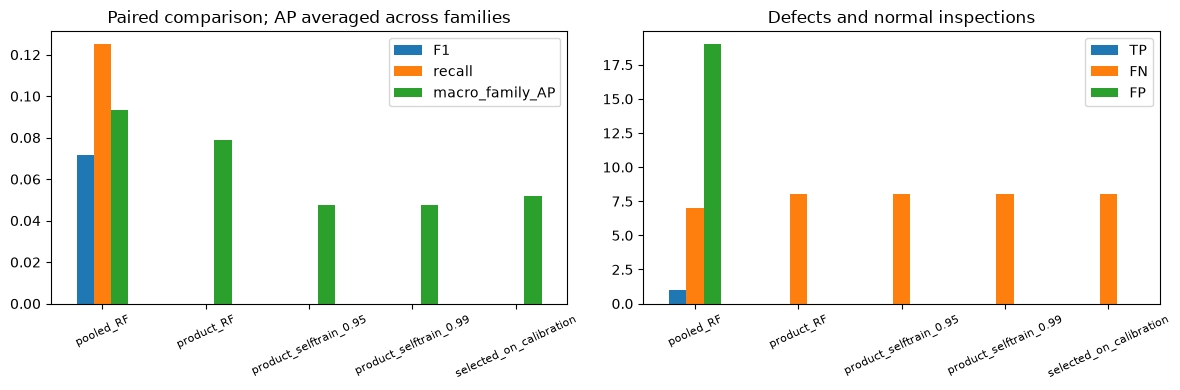

In [5]:
report=[];predictions=[]
for family,(a,v,e,pool) in data.items():
    specs={'pooled_RF':(pooled,use,pooled_threshold),
           'product_RF':candidate_models[(family,'supervised')],
           'product_selftrain_0.99':candidate_models[(family,'selftrain_0.99')],
           'product_selftrain_0.95':candidate_models[(family,'selftrain_0.95')],
           'selected_on_calibration':candidate_models[(family,selection[family])]}
    for name,(m,features,t) in specs.items():
        score=m.predict_proba(e[features])[:,1]
        report.append(dict(family=family,method=name,threshold=t,**metrics(e.defect,score,t)))
        x=e[['_id','time','PART_NAME','family','defect','Reason']].copy()
        x['method']=name;x['score']=score;x['pred']=(score>=t).astype(int)
        predictions.append(x)
report=pd.DataFrame(report);predictions=pd.concat(predictions,ignore_index=True)
aggregate=report.groupby('method')[['TP','FN','FP','TN','inspections']].sum()
aggregate['precision']=aggregate.TP/(aggregate.TP+aggregate.FP).replace(0,np.nan)
aggregate['recall']=aggregate.TP/(aggregate.TP+aggregate.FN)
aggregate['F1']=2*aggregate.TP/(2*aggregate.TP+aggregate.FP+aggregate.FN)
aggregate['macro_family_AP']=report.groupby('method').AP.mean()
display(report);display(aggregate)
assert (aggregate[['TP','FN','FP','TN']].sum(axis=1)==1000).all()
assert (aggregate.TP+aggregate.FN==8).all()
fig,axes=plt.subplots(1,2,figsize=(12,4))
aggregate[['F1','recall','macro_family_AP']].plot.bar(ax=axes[0],rot=25)
aggregate[['TP','FN','FP']].plot.bar(ax=axes[1],rot=25)
axes[0].set_title('Paired comparison; AP averaged across families');axes[1].set_title('Defects and normal inspections')
for ax in axes:ax.set_xlabel('');ax.tick_params(axis='x',labelsize=8)
fig.tight_layout();plt.show()

## 5. 양품 패턴 기반 소형 오토인코더 추가 비교

제품별·준지도 RF의 탐지 성능이 부족하여 정상 패턴 복원을 비교한다. 이 추가 후보도 조정 구간으로 선택하며 평가 결과로 튜닝하지 않는다. 순차적으로 진행한 탐색 실험이므로 신규 독립 평가가 아니다.

실제 양품 학습 데이터만 사용한다. 학습 양품으로 하나의 StandardScaler를 맞추고, 같은 변환을 양품/불량 모두에 적용한다. 라벨별 별도 스케일링을 하지 않는다. 15→5→15 은닉층의 작은 신경망이 표준화된 입력을 복원한다. 학습 입력에는 표준편차 0.03의 잡음을 더하고 목표는 잡음 없는 입력으로 둔다. MLPRegressor로 구현한 CPU 기반 잡음 제거 오토인코더이며, 불량 라벨을 회귀하는 모델이 아니다.

고정 설정: Adam, 최대 300 epoch, batch 32, 학습률 0.001, 실제 학습 양품 중 20%를 내부 조기종료에 사용. 조정/평가 데이터는 신경망 학습에 사용하지 않는다. 복원 MSE가 클수록 이상 점수다. 조정 구간에서 동일한 검사 10% 이내 F1 최대 기준을 적용한다. 제품별 조정 AP로 RF 후보와 AE 중 선택한 결과를 별도로 보고한다.

<local-runtime>/cell.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


<local-runtime>/cell.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,family,normal_training_rows,inputs,epochs
0,CN7,1194,23,300
1,RG3,667,24,300


,family,model,threshold,AP,ROC_AUC,precision,recall,F1,TP,FN,FP,TN,inspections,inspection_rate
0,CN7,autoencoder,411105.109273,0.004933,0.338259,0.000000,0.0,0.000000,0,10,0,1827,0,0.000
1,RG3,autoencoder,2.510920,0.020539,0.422857,0.041667,0.1,0.058824,1,9,23,467,24,0.048


조정 AP에 따른 RF/AE 선택: {'CN7': 'supervised', 'RG3': 'selftrain_0.99'}


,family,method,threshold,AP,ROC_AUC,precision,recall,F1,TP,FN,FP,TN,inspections,inspection_rate
0,CN7,pooled_RF,0.079060,0.050000,0.979459,0.000000,0.000000,0.000000,0,1,0,925,0,0.00000
5,RG3,pooled_RF,0.079060,0.136452,0.321962,0.050000,0.142857,0.074074,1,6,19,48,20,0.27027
10,CN7,product_autoencoder,411105.109273,0.006173,0.826486,0.000000,0.000000,0.000000,0,1,0,925,0,0.00000
11,CN7,selected_RF_or_AE,0.033463,0.014493,0.927027,0.000000,0.000000,0.000000,0,1,0,925,0,0.00000
12,RG3,product_autoencoder,2.510920,0.183087,0.549041,0.094595,1.000000,0.172840,7,0,67,0,74,1.00000
13,RG3,selected_RF_or_AE,0.127381,0.089248,0.304904,0.000000,0.000000,0.000000,0,7,0,67,0,0.00000


,TP,FN,FP,TN,inspections,precision,recall,F1,macro_family_AP
method,,,,,,,,,
pooled_RF,1,7,19,973,20,0.050000,0.125,0.071429,0.093226
product_RF,0,8,0,992,0,NaN,0.000,0.000000,0.079056
product_autoencoder,7,1,67,925,74,0.094595,0.875,0.170732,0.094630
product_selftrain_0.95,0,8,0,992,0,NaN,0.000,0.000000,0.047371
product_selftrain_0.99,0,8,0,992,0,NaN,0.000,0.000000,0.047371
selected_RF_or_AE,0,8,0,992,0,NaN,0.000,0.000000,0.051870
selected_on_calibration,0,8,0,992,0,NaN,0.000,0.000000,0.051870


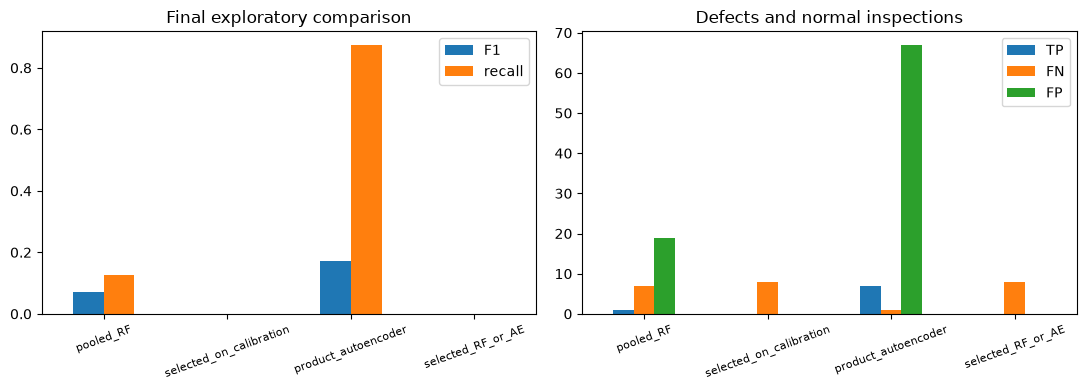

In [6]:
from sklearn.neural_network import MLPRegressor
ae_models={};ae_cal_rows=[];ae_training=[];ae_selection={}
ae_reports=[];ae_predictions=[]
for family,(a,v,e,pool) in data.items():
    normal=a.loc[a.defect.eq(0)]
    cols=[c for c in numeric if normal[c].nunique(dropna=True)>1]
    transform=Pipeline([('impute',SimpleImputer(strategy='median')),('scale',StandardScaler())])
    xn=transform.fit_transform(normal[cols])
    rng=np.random.default_rng(42)
    noisy=xn+rng.normal(0,.03,xn.shape)
    ae=MLPRegressor(hidden_layer_sizes=(15,5,15),activation='relu',solver='adam',
        learning_rate_init=.001,max_iter=300,batch_size=32,early_stopping=True,
        validation_fraction=.2,n_iter_no_change=20,random_state=42)
    ae.fit(noisy,xn)
    def reconstruction_scores(frame):
        x=transform.transform(frame[cols])
        return np.mean((ae.predict(x)-x)**2,axis=1)
    vs=reconstruction_scores(v)
    threshold=choose(v.defect,vs)
    ae_cal_rows.append(dict(family=family,model='autoencoder',threshold=threshold,**metrics(v.defect,vs,threshold)))
    ae_training.append(dict(family=family,normal_training_rows=len(normal),inputs=len(cols),epochs=int(ae.n_iter_)))
    previous=calibration.loc[calibration.family.eq(family)&calibration.model.eq(selection[family])].iloc[0]
    use_ae=average_precision_score(v.defect,vs)>previous.AP
    ae_selection[family]='autoencoder' if use_ae else selection[family]
    ae_score=reconstruction_scores(e)
    m,features,rf_threshold=candidate_models[(family,selection[family])]
    rf_score=m.predict_proba(e[features])[:,1]
    for method,score,t in [('product_autoencoder',ae_score,threshold),
                         ('selected_RF_or_AE',ae_score if use_ae else rf_score,threshold if use_ae else rf_threshold)]:
        ae_reports.append(dict(family=family,method=method,threshold=t,**metrics(e.defect,score,t)))
        x=e[['_id','time','PART_NAME','family','defect','Reason']].copy()
        x['method']=method;x['score']=score;x['pred']=(score>=t).astype(int);ae_predictions.append(x)
display(pd.DataFrame(ae_training));display(pd.DataFrame(ae_cal_rows))
print('조정 AP에 따른 RF/AE 선택:',ae_selection)
report=pd.concat([report,pd.DataFrame(ae_reports)],ignore_index=True)
predictions=pd.concat([predictions,*ae_predictions],ignore_index=True)
aggregate=report.groupby('method')[['TP','FN','FP','TN','inspections']].sum()
aggregate['precision']=aggregate.TP/(aggregate.TP+aggregate.FP).replace(0,np.nan)
aggregate['recall']=aggregate.TP/(aggregate.TP+aggregate.FN)
aggregate['F1']=2*aggregate.TP/(2*aggregate.TP+aggregate.FP+aggregate.FN)
aggregate['macro_family_AP']=report.groupby('method').AP.mean()
display(report.loc[report.method.isin(['pooled_RF','product_autoencoder','selected_RF_or_AE'])])
display(aggregate)
assert (aggregate[['TP','FN','FP','TN']].sum(axis=1)==1000).all()
assert (aggregate.TP+aggregate.FN==8).all()
fig,axes=plt.subplots(1,2,figsize=(11,4))
shown=aggregate.loc[['pooled_RF','selected_on_calibration','product_autoencoder','selected_RF_or_AE']]
shown[['F1','recall']].plot.bar(ax=axes[0],rot=20)
shown[['TP','FN','FP']].plot.bar(ax=axes[1],rot=20)
for ax in axes:ax.set_xlabel('');ax.tick_params(axis='x',labelsize=8)
axes[0].set_title('Final exploratory comparison');axes[1].set_title('Defects and normal inspections')
fig.tight_layout();plt.show()

## 저장 결과의 해석

추가 자료의 같은 설비·제품 71,180건에서, 라벨 자료와 생산 시각·설비·제품이 겹치는 1,984건과 추가 자료 자체의 중복 사건 168행을 제외해 69,028건을 남겼다. 실제 과거 30일 학습 후보는 CN7 18,240건, RG3 7,892건이다. 중복 사건 168행은 84개 사건 키에 해당한다.

두 확신도 기준 모두 CN7 1,000건, RG3 666건의 가상 양품만 추가했다. 가상 불량은 0건이었다. 기존 RF가 확신하는 양품을 더하는 효과만 있었으며, 부족한 불량 패턴을 확보한 것은 아니다. 실제 라벨 추가와 혼동하지 않는다.

조정 AP로 CN7 지도 RF, RG3 준지도 RF(0.99)가 선택됐으나, 평가에서는 TP 0/FN 8/FP 0이었다. 같은 재분리의 통합 RF는 TP 1/FN 7/FP 19였다. 제품별 지도·준지도 모델로 개선을 확보하지 못했다.

오토인코더는 TP 7/FN 1/FP 67, 재현율 87.5%, F1 0.1707을 보였지만 **RG3 평가 74건 전체를 이상으로 판정한 결과**다. 정상과 불량을 실용적으로 구분한 것으로 보지 않는다. 두 제품군 모두 조정 AP가 RF 후보보다 낮아 선택되지 않았다. 두 신경망은 최대 300 epoch에 도달했으므로 충분히 수렴한 최적 AE라고 주장하지 않는다.

최종 판단은 제품별·준지도·정상 복원 모델의 효과가 이번 설정과 미래 구간에서 확인되지 않았다는 것이다. 데이터 활용·모델링·평가 방식을 재검토하고 실패 원인을 기록했으며, 새로운 평가 데이터를 확보하지 않은 추가 튜닝을 반복하지 않았다. 이전 실험과 학습/조정 구성이 달라 직접 개선율을 계산하지 않는다.


## 6. 해석과 출처

기존 실험과 달리 RG3 학습일 하나를 조정용으로 유보했다. 이 변경 때문에 이전 수치와 직접 증감률을 계산하지 않고 이번의 통합 RF와 비교한다. 추가 라벨 없는 데이터의 제품별 30일 범위, 이벤트 중복 제외, 의사 라벨별 추가량을 함께 보고한다. 데이터 추가가 반드시 성능 향상으로 이어지지 않으며 의사 라벨 오류 확대 가능성이 있다.

불량 8건, 제품별 라벨 부족, 짧은 평가 기간이라는 한계는 남는다. 제조 현장 성능·비용 절감·원인 규명으로 해석하지 않는다.

출처: 중소벤처기업부, Korea AI Manufacturing Platform(KAMP), 사출성형기 AI 데이터셋, KAIST(울산과학기술원, ㈜이피엠솔루션즈), 2020.12.14., https://www.kamp-ai.kr/

제공 분석 자료의 데이터 활용 설명을 참고했다. 연구/공식 활용 시 출처와 활용 내용·문서 이메일(kamp@kaist.ac.kr) 안내가 있다. 이메일은 발송하지 않았다.

In [7]:
import importlib.metadata as metadata
summary=dict(audit=audit,splits=split_rows,selection=selection,calibration=calibration.to_dict('records'),
 ae_calibration=ae_cal_rows,ae_training=ae_training,ae_selection=ae_selection,
 pseudo_counts=pseudo_rows,evaluation=report.to_dict('records'),aggregate=aggregate.reset_index().to_dict('records'),
 source_sha256=source_sha256,unlabeled_sha256=hashlib.sha256(UNLABELED_PATH.read_bytes()).hexdigest(),
 versions={x:metadata.version(x) for x in ['numpy','pandas','scikit-learn','matplotlib']})
if os.environ.get('MOLDING_RESULT_DIR'):
    out=Path(os.environ['MOLDING_RESULT_DIR']);out.mkdir(parents=True,exist_ok=True)
    (out/'semisupervised_summary.json').write_text(json.dumps(summary,ensure_ascii=False,indent=2),encoding='utf-8')
    predictions.to_csv(out/'semisupervised_predictions.csv',index=False)
print('제품별 지도·준지도 비교 완료')

제품별 지도·준지도 비교 완료
